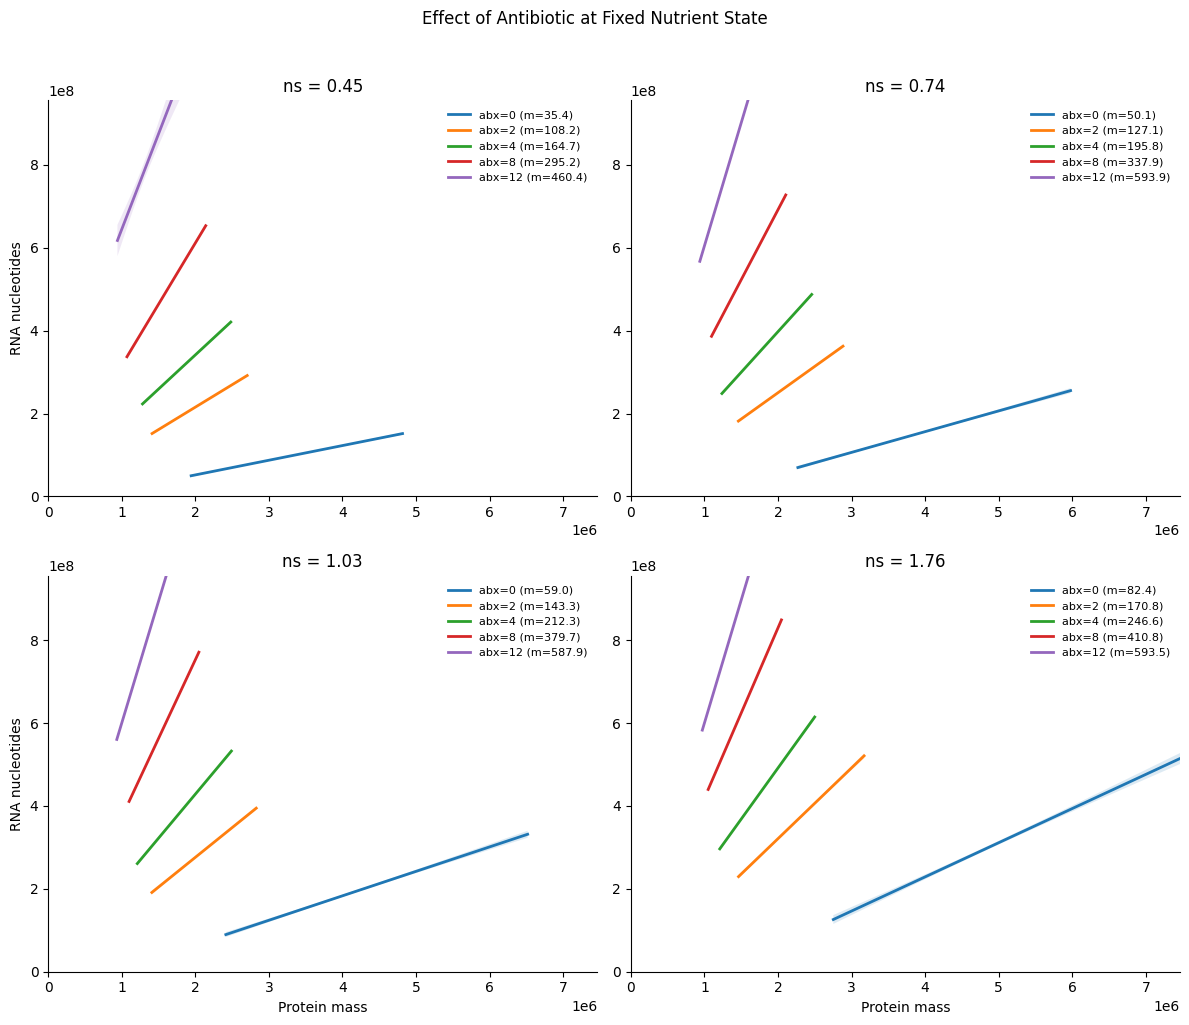

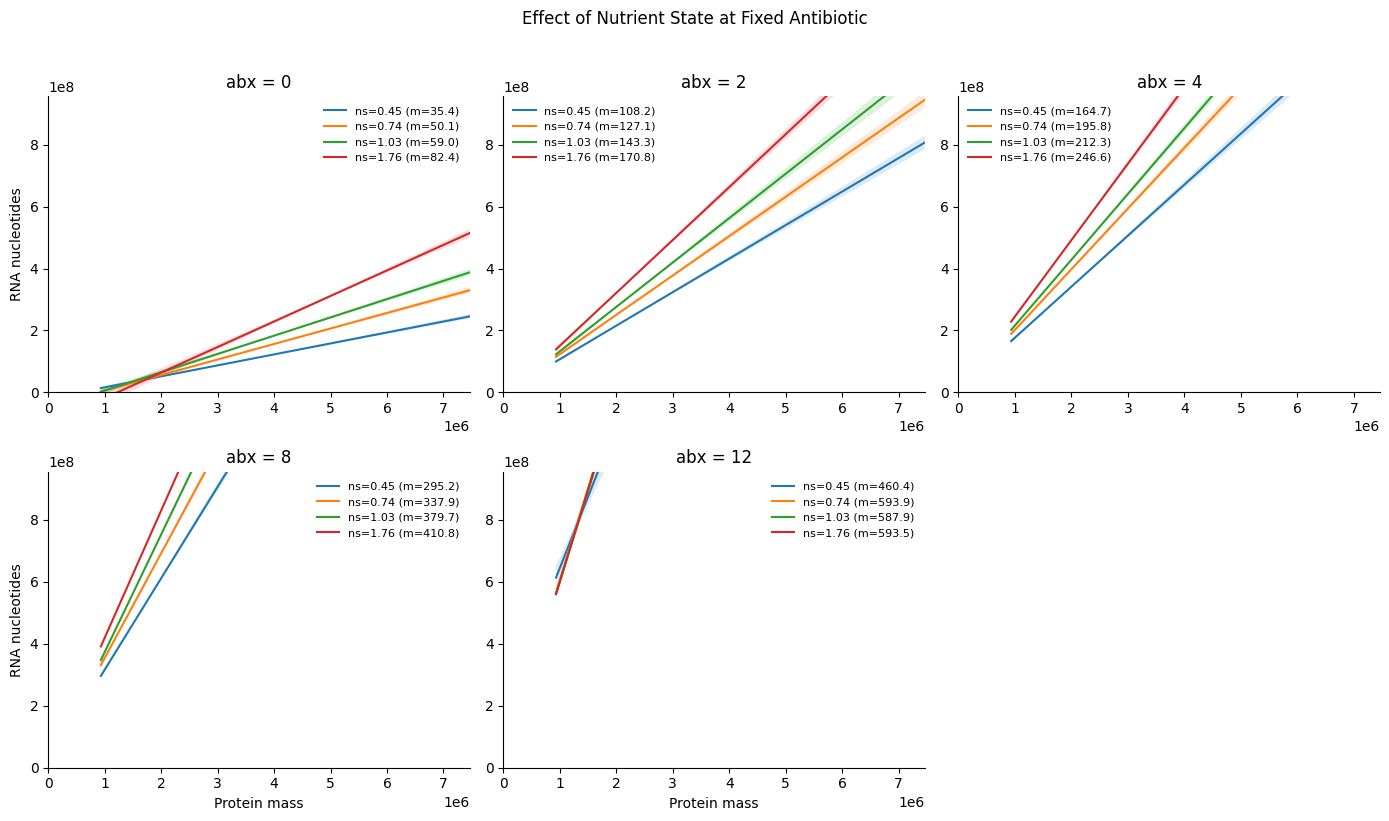

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
ns_list = [0.45, 0.74, 1.03, 1.76]
abx_levels = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

# ============================================================
# FILE MAP
# ============================================================
FILES = {}

for ns in ns_list:
    ns_str = str(ns).replace(".", "")
    for abx in abx_levels:
        if abx == 0:
            FILES[(ns, abx)] = f"Data/ns{ns_str}.arrow"
        else:
            FILES[(ns, abx)] = f"Data/ns{ns_str}/abx{abx}.arrow"

# ============================================================
# HELPERS
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def compute_time_since_division(t, total_mass):
    div_idx = detect_divisions_from_mass(total_mass)
    tau = np.zeros_like(t)
    last_div_time = t[0]
    div_set = set(div_idx)

    for i in range(len(t)):
        if i in div_set:
            last_div_time = t[i]
        tau[i] = t[i] - last_div_time

    return tau

def sample_random_per_cycle(total_mass, guard_frac=0.1, seed=0):
    rng = np.random.default_rng(seed)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass)-1]))

    sample_indices = []

    for i in range(len(div_idx)-1):
        start = div_idx[i]
        end   = div_idx[i+1]
        L = end - start
        if L < 10:
            continue
        g = int(guard_frac * L)
        lo = start + g
        hi = end - g
        if hi <= lo:
            continue
        sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

def iqr_mask(x, k=1.5):
    q1 = np.percentile(x, 25)
    q3 = np.percentile(x, 75)
    iqr = q3 - q1
    return (x >= q1 - k*iqr) & (x <= q3 + k*iqr)

def fit_with_ci(x, y, x_grid):
    n = len(x)
    coef = np.polyfit(x, y, 1)
    y_hat = np.polyval(coef, x)
    s_err = np.sqrt(np.sum((y - y_hat)**2) / (n - 2))
    x_mean = np.mean(x)
    Sxx = np.sum((x - x_mean)**2)
    y_pred = np.polyval(coef, x_grid)
    se = s_err * np.sqrt(1/n + (x_grid - x_mean)**2 / Sxx)
    ci = 1.96 * se
    return coef, y_pred, ci

# ============================================================
# LOAD DATA
# ============================================================
data = {}

for key, fn in FILES.items():
    df = load_arrow(fn)
    df = df[df["timestamp"] >= BURN_IN]

    t = df["timestamp"].to_numpy()
    mass = compute_mass(df)
    prot = compute_protein(df)
    rna = compute_RNA_nt(df)
    tau = compute_time_since_division(t, mass)

    idx = sample_random_per_cycle(mass)

    data[key] = dict(
        protein=prot[idx],
        rna=rna[idx],
        tau=tau[idx]
    )

# ============================================================
# GLOBAL AXIS LIMITS
# ============================================================
all_prot = []
all_rna = []

for key in data:
    mask = iqr_mask(data[key]["tau"])
    all_prot.append(data[key]["protein"][mask])
    all_rna.append(data[key]["rna"][mask])

global_min_x = min(arr.min() for arr in all_prot)
global_max_x = max(arr.max() for arr in all_prot)
global_min_y = min(arr.min() for arr in all_rna)
global_max_y = max(arr.max() for arr in all_rna)

# ============================================================
# FIGURE 1: FIX NS, VARY ABX
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, ns in enumerate(ns_list):
    ax = axes[i]

    for abx in abx_levels:
        d = data[(ns, abx)]
        mask = iqr_mask(d["tau"])
        x = d["protein"][mask]
        y = d["rna"][mask]

        # x_grid = np.linspace(global_min_x, global_max_x, 200)
        x_grid = np.linspace(x.min(), x.max(), 200)

        coef, y_pred, ci = fit_with_ci(x, y, x_grid)

        abx_colors = {
        0: "#1f77b4",
        2: "#ff7f0e",
        4: "#2ca02c",
        8: "#d62728",
        12: "#9467bd"
        }

        ax.plot(x_grid, y_pred,
        color=abx_colors[abx],
        linewidth=2,
        label=f"abx={abx} (m={coef[0]:.1f})")
        ax.fill_between(x_grid, y_pred-ci, y_pred+ci, alpha=0.15)

    ax.set_title(f"ns = {ns}")
    ax.set_xlim(0, global_max_x)
    global_max_y = np.percentile(np.concatenate(all_rna), 98)
    ax.set_ylim(0, global_max_y)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=8)


axes[2].set_xlabel("Protein mass")
axes[3].set_xlabel("Protein mass")
axes[0].set_ylabel("RNA nucleotides")
axes[2].set_ylabel("RNA nucleotides")

plt.suptitle("Effect of Antibiotic at Fixed Nutrient State", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# FIGURE 2: FIX ABX, VARY NS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, abx in enumerate(abx_levels):
    ax = axes[i]

    for ns in ns_list:
        d = data[(ns, abx)]
        mask = iqr_mask(d["tau"])
        x = d["protein"][mask]
        y = d["rna"][mask]

        x_grid = np.linspace(global_min_x, global_max_x, 200)
        coef, y_pred, ci = fit_with_ci(x, y, x_grid)

        ax.plot(
            x_grid,
            y_pred,
            label=f"ns={ns} (m={coef[0]:.1f})"
        )
        ax.fill_between(x_grid, y_pred-ci, y_pred+ci, alpha=0.15)

    ax.set_title(f"abx = {abx}")
    ax.set_xlim(0, global_max_x)
    ax.set_ylim(0, global_max_y)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=8)
fig.delaxes(axes[-1])
axes[3].set_xlabel("Protein mass")
axes[4].set_xlabel("Protein mass")
axes[0].set_ylabel("RNA nucleotides")
axes[3].set_ylabel("RNA nucleotides")

plt.suptitle("Effect of Nutrient State at Fixed Antibiotic", y=1.02)
plt.tight_layout()
plt.show()


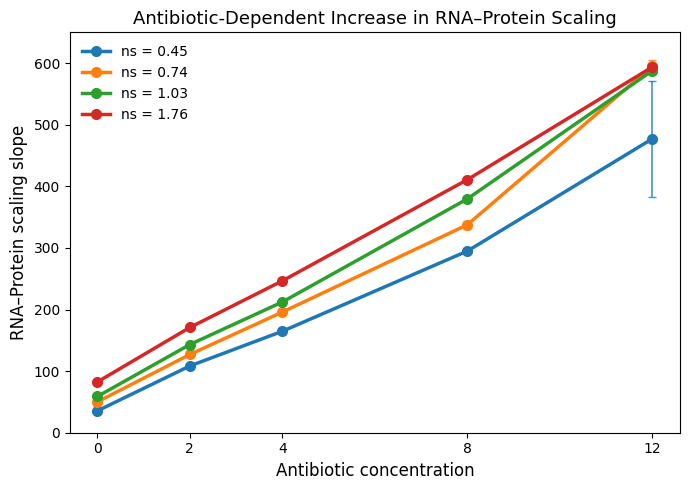

In [27]:
# ============================================================
# PUBLICATION-QUALITY SLOPE vs ANTIBIOTIC
# ============================================================

plt.figure(figsize=(7,5))

ns_colors = {
    0.45: "#1f77b4",
    0.74: "#ff7f0e",
    1.03: "#2ca02c",
    1.76: "#d62728"
}

for ns in ns_list:

    mean_vals = np.array(slope_mean[ns])
    std_vals  = np.array(slope_std[ns])

    plt.plot(
        abx_levels,
        mean_vals,
        marker="o",
        markersize=7,
        linewidth=2.5,
        color=ns_colors[ns],
        label=f"ns = {ns}"
    )

    plt.errorbar(
        abx_levels,
        mean_vals,
        yerr=std_vals,
        fmt="none",
        ecolor=ns_colors[ns],
        elinewidth=1.2,
        capsize=3,
        alpha=0.8
    )

plt.xlabel("Antibiotic concentration", fontsize=12)
plt.ylabel("RNA–Protein scaling slope", fontsize=12)
plt.title("Antibiotic-Dependent Increase in RNA–Protein Scaling", fontsize=13)

plt.ylim(0, 650)
plt.xticks(abx_levels)

plt.legend(frameon=False)
plt.grid(False)

plt.tight_layout()
plt.show()


In [28]:
import pandas as pd

rows = []

for ns in ns_list:
    for i, abx in enumerate(abx_levels):
        rows.append({
            "ns": ns,
            "abx": abx,
            "slope": slope_mean[ns][i]
        })

df_slopes = pd.DataFrame(rows)
import statsmodels.formula.api as smf

model = smf.ols("slope ~ abx * ns", data=df_slopes).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  slope   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     300.7
Date:                Fri, 20 Feb 2026   Prob (F-statistic):           2.82e-14
Time:                        11:55:35   Log-Likelihood:                -92.019
No. Observations:                  20   AIC:                             192.0
Df Residuals:                      16   BIC:                             196.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.9738     21.479      0.278      0.7

A linear interaction model revealed a strong main effect of antibiotic concentration on RNA–protein scaling (β = 38.3 ± 3.2, p < 0.001), and a smaller but significant main effect of nutrient state (β = 42.3 ± 19.4, p = 0.044). The interaction between antibiotic and nutrient state was not significant (p = 0.29), indicating that antibiotic-induced scaling increases occur approximately in parallel across nutrient conditions. Together, these factors explain 98% of the variance in scaling slope (R² = 0.983).

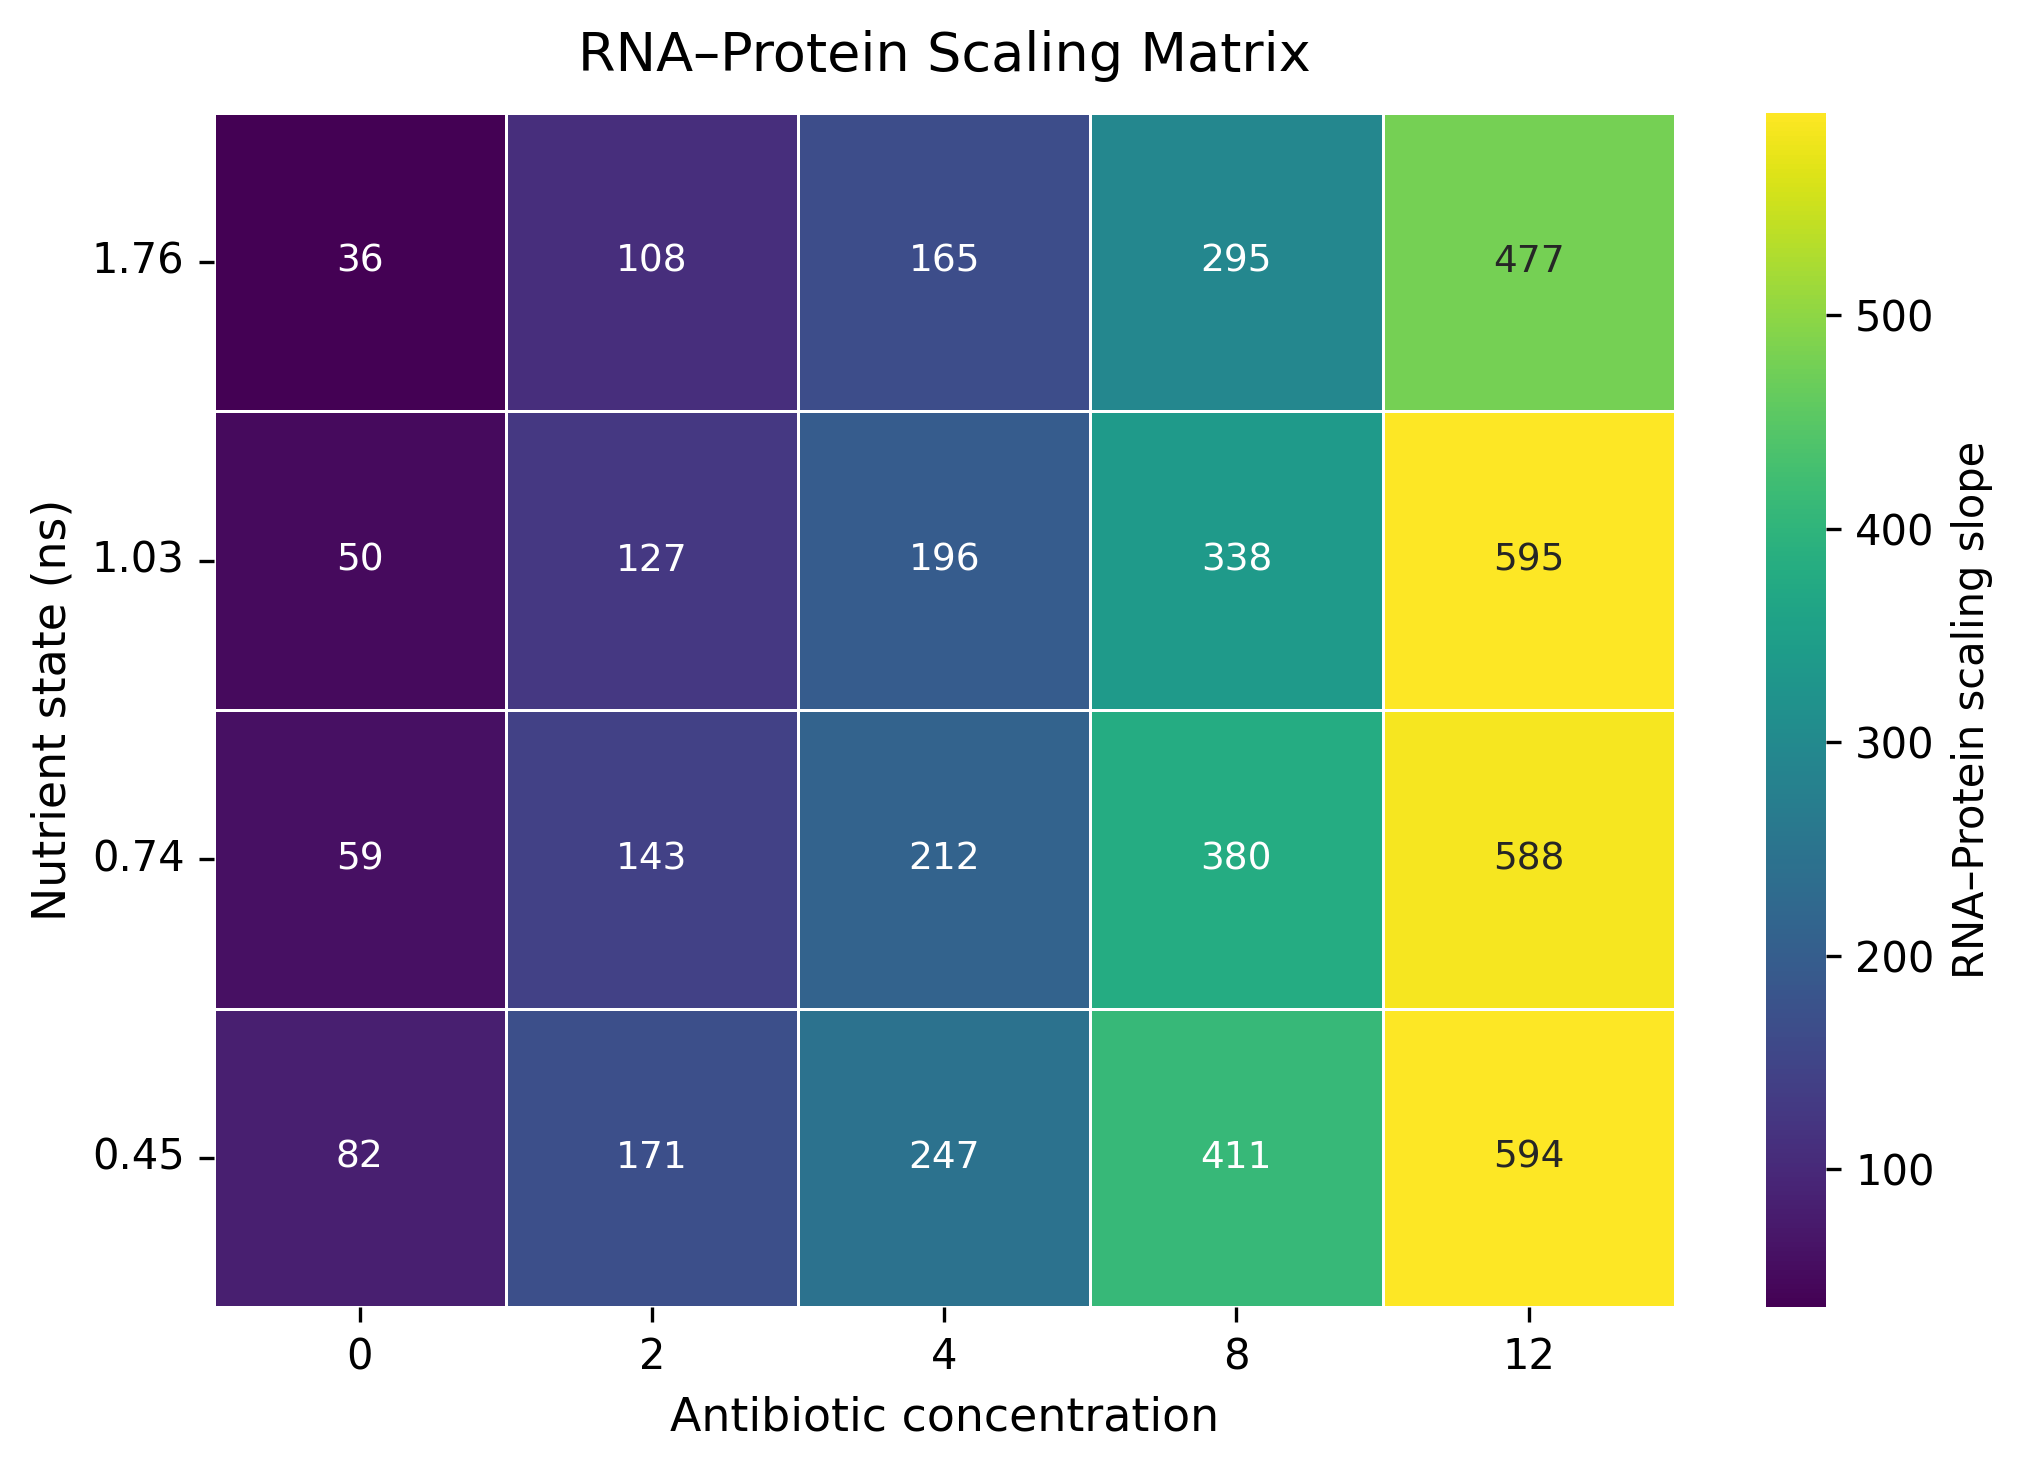

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------------
# DATA
# ------------------------------------------------------------
ns_vals = [1.76, 1.03, 0.74, 0.45] #[0.45, 0.74, 1.03, 1.76]
abx_vals = [0, 2, 4, 8, 12]

df_heatmap = pd.DataFrame(
    heatmap_array,
    index=ns_vals,
    columns=abx_vals
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
plt.figure(figsize=(7,5), dpi=300)

ax = sns.heatmap(
    df_heatmap,
    cmap="viridis",
    annot=True,
    fmt=".0f",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "RNA–Protein scaling slope"},
    annot_kws={"size":9}
)

# Labels
ax.set_xlabel("Antibiotic concentration", fontsize=11)
ax.set_ylabel("Nutrient state (ns)", fontsize=11)
ax.set_title("RNA–Protein Scaling Matrix", fontsize=13, pad=10)

# Improve ticks
ax.set_xticklabels(abx_vals, rotation=0)
ax.set_yticklabels(ns_vals, rotation=0)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


      ns  abx  corr_ratio_rna  corr_ratio_protein
0   0.45    0        0.666185            0.252488
1   0.45    2        0.384814            0.020359
2   0.45    4        0.189961           -0.121124
3   0.45    8        0.073512           -0.173788
4   0.45   12        0.064004           -0.451850
5   0.74    0        0.766349            0.369334
6   0.74    2        0.419498            0.026902
7   0.74    4        0.255806           -0.056365
8   0.74    8        0.183886           -0.088791
9   0.74   12        0.063350           -0.082518
10  1.03    0        0.774769            0.381420
11  1.03    2        0.498239            0.090383
12  1.03    4        0.283170           -0.024633
13  1.03    8        0.282365            0.046403
14  1.03   12       -0.061250           -0.161658
15  1.76    0        0.813605            0.411873
16  1.76    2        0.485335            0.130570
17  1.76    4        0.331525            0.012512
18  1.76    8        0.096807           -0.065373


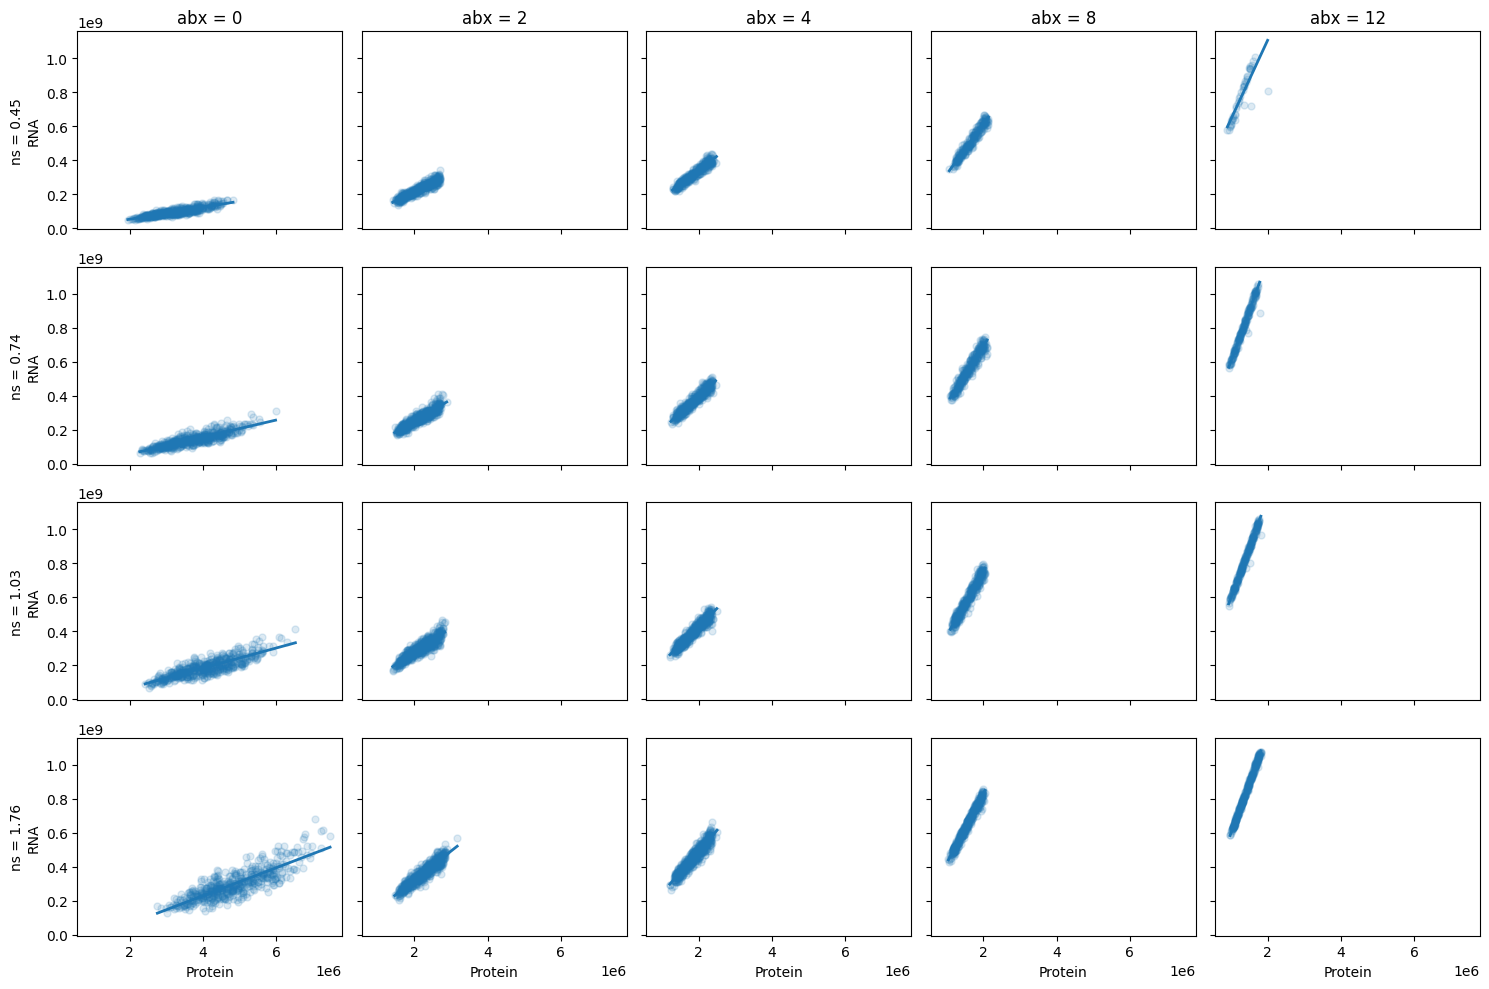

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0
SAMPLING_MODE = "random"  # "pre", "post", "random"

# ============================================================
# HELPERS
# ============================================================
def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (
        df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]
    ).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)

    return ribo_mass, non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def pearson_corr(x, y):
    return np.corrcoef(x, y)[0, 1]

# ------------------------------------------------------------
# Detect division peaks from total mass
# ------------------------------------------------------------
def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    max_indices = np.where(dslope == -2)[0] + 1
    return max_indices

# ------------------------------------------------------------
# Sample one point per cell cycle
# ------------------------------------------------------------
def sample_one_per_cycle(total_mass, guard_frac=0.1, rng=None):
    """
    Pick one random index per detected cell cycle.
    guard_frac trims the first/last fraction of each cycle to avoid division artefacts.
    """
    if rng is None:
        rng = np.random.default_rng(0)  # reproducible

    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass) - 1]))

    sample_indices = []

    for i in range(len(div_idx) - 1):
        start = div_idx[i]
        end   = div_idx[i + 1]

        L = end - start
        if L < 10:
            continue

        g = int(guard_frac * L)
        lo = start + g
        hi = end - g

        if hi <= lo:
            continue

        sample_indices.append(rng.integers(lo, hi))

    return np.array(sample_indices)

def sample_pre_division(total_mass, offset=1):
    """
    Take a point just BEFORE each division peak.
    offset=1 means one index before the peak.
    """
    div_idx = detect_divisions_from_mass(total_mass)

    sample_indices = []

    for d in div_idx:
        idx = d - offset
        if idx > 0:
            sample_indices.append(idx)

    return np.array(sample_indices)

def sample_post_division(total_mass, offset=1):
    """
    Take a point just AFTER each division peak.
    offset=1 means one index after the peak.
    """
    div_idx = detect_divisions_from_mass(total_mass)

    sample_indices = []

    for d in div_idx:
        idx = d + offset
        if idx < len(total_mass):
            sample_indices.append(idx)

    return np.array(sample_indices)


# ============================================================
# SWEEP ALL CONDITIONS (cycle sampled)
# ============================================================
records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, non_ribo_mass = compute_mass(df)
        total_mass = ribo_mass + non_ribo_mass

        protein = compute_protein(df) #/ total_mass
        rna     = compute_RNA_nt(df) #/ total_mass
        ratio   = rna / protein

        if SAMPLING_MODE == "pre":
            idx = sample_pre_division(total_mass)
        elif SAMPLING_MODE == "post":
            idx = sample_post_division(total_mass)
        elif SAMPLING_MODE == "random":
            idx = sample_one_per_cycle(total_mass)


        # idx = sample_one_per_cycle(total_mass)
        # idx = sample_pre_division(total_mass)
        # idx = sample_post_division(total_mass)

        protein = protein[idx]
        rna     = rna[idx]
        ratio   = ratio[idx]

        records.append({
            "ns": ns,
            "abx": abx,
            "corr_ratio_rna": pearson_corr(rna, ratio),
            "corr_ratio_protein": pearson_corr(protein, ratio),
        })

df_all = pd.DataFrame(records)
print(df_all.sort_values(["ns", "abx"]))

# ============================================================
# PLOT GRID: RNA vs Protein (mass-normalized, cycle sampled)
# ============================================================

fig, axes = plt.subplots(len(NS_VALUES), len(ABX_VALUES),
                         figsize=(15, 10),
                         sharex=True, sharey=True)

for i, ns in enumerate(NS_VALUES):
    for j, abx in enumerate(ABX_VALUES):

        # Correct file path logic
        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        ribo_mass, non_ribo_mass = compute_mass(df)
        total_mass = ribo_mass + non_ribo_mass

        protein = compute_protein(df) #/ total_mass
        rna     = compute_RNA_nt(df) #/ total_mass

        # Sampling
        if SAMPLING_MODE == "pre":
            idx = sample_pre_division(total_mass)
        elif SAMPLING_MODE == "post":
            idx = sample_post_division(total_mass)
        else:
            idx = sample_one_per_cycle(total_mass)

        protein = protein[idx]
        rna     = rna[idx]

        ax = axes[i, j]

        # Scatter
        ax.scatter(protein, rna, s=25, alpha=0.15)

        # Regression line
        if len(protein) > 2:
            coef = np.polyfit(protein, rna, 1)
            x_grid = np.linspace(protein.min(), protein.max(), 100)
            y_pred = np.polyval(coef, x_grid)
            ax.plot(x_grid, y_pred, linewidth=2)

        # Titles and labels
        if i == 0:
            ax.set_title(f"abx = {abx}")

        if j == 0:
            ax.set_ylabel(f"ns = {ns}\nRNA")

        if i == len(NS_VALUES) - 1:
            ax.set_xlabel("Protein")

plt.tight_layout()
plt.show()


RAMAN DATA


               0         2         4         8         12
gly      0.289333  0.383736  0.537095  0.650143  0.781489
glu      0.495203  0.385832  0.518591  0.481788  0.654838
caa_gly  0.351680  0.514298  0.567110  0.657143  0.654028
caa_glu  0.676843  0.239632  0.726312  0.752360  0.537909


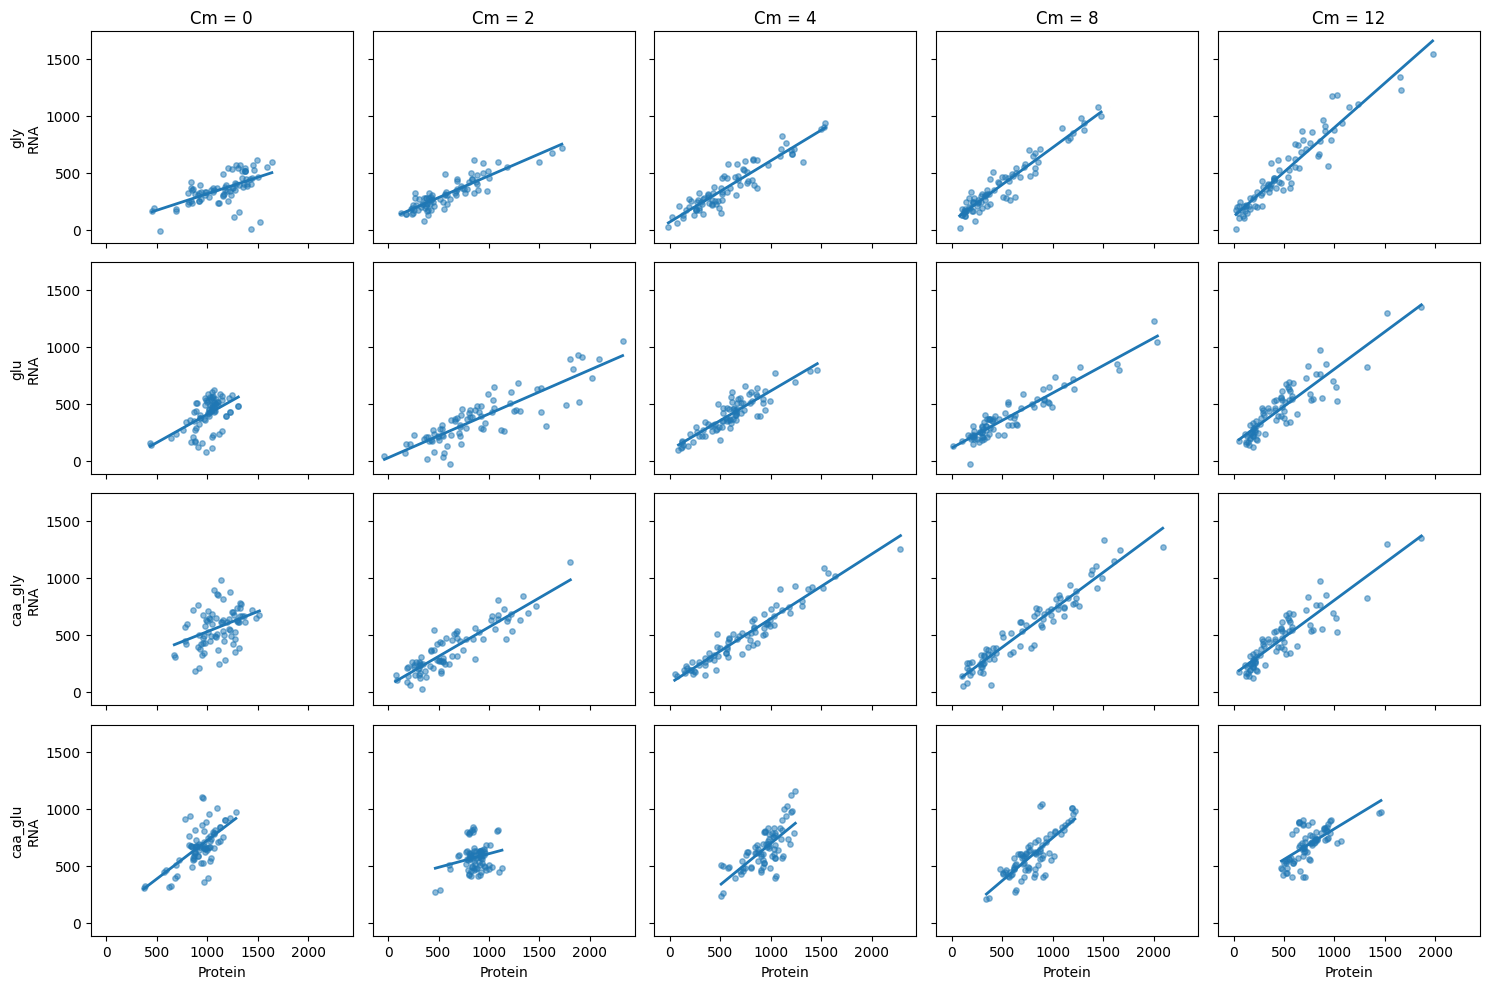

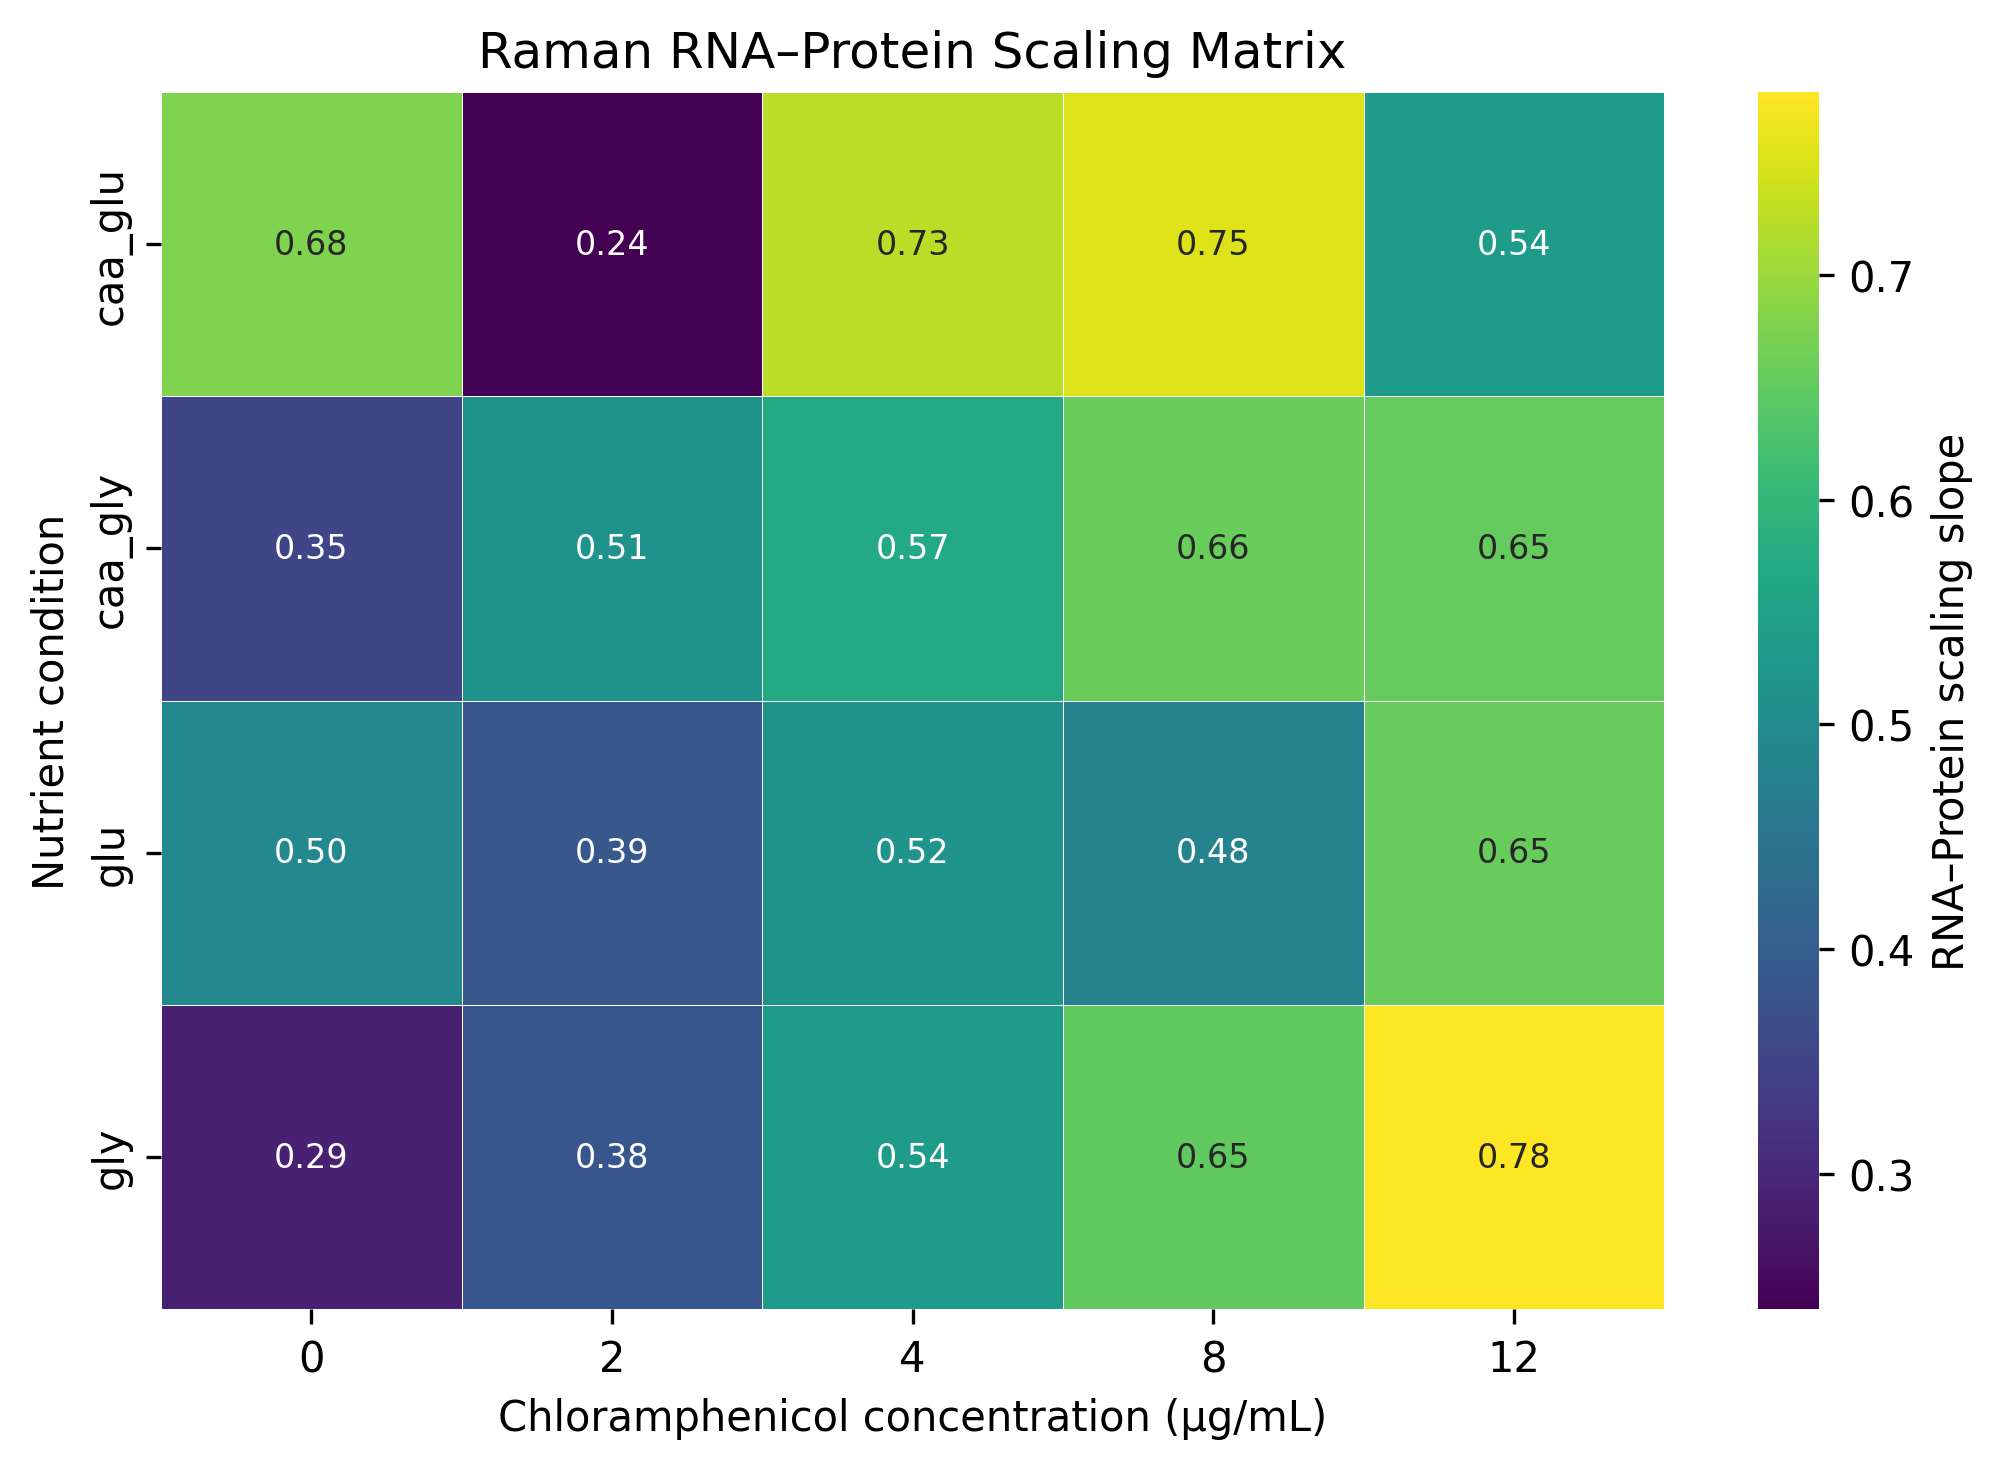

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD RAMAN DATA
# ============================================================
rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")

nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
cm_levels = [0, 2, 4, 8, 12]

# ============================================================
# COMPUTE SLOPES
# ============================================================
slope_matrix = np.zeros((len(nutrients), len(cm_levels)))

for i, nutrient in enumerate(nutrients):
    for j, cm in enumerate(cm_levels):

        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns or col not in protein_df.columns:
            slope_matrix[i, j] = np.nan
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA  = RNA[:N]
        PROT = PROT[:N]

        if len(PROT) > 2:
            coef = np.polyfit(PROT, RNA, 1)
            slope_matrix[i, j] = coef[0]
        else:
            slope_matrix[i, j] = np.nan

# Convert to DataFrame
df_slopes = pd.DataFrame(
    slope_matrix,
    index=nutrients,
    columns=cm_levels
)

print(df_slopes)
fig, axes = plt.subplots(
    len(nutrients),
    len(cm_levels),
    figsize=(15, 10),
    sharex=True,
    sharey=True
)

for i, nutrient in enumerate(nutrients):
    for j, cm in enumerate(cm_levels):

        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns or col not in protein_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA  = RNA[:N]
        PROT = PROT[:N]

        ax = axes[i, j]
        ax.scatter(PROT, RNA, s=15, alpha=0.5)

        if len(PROT) > 2:
            coef = np.polyfit(PROT, RNA, 1)
            x_grid = np.linspace(PROT.min(), PROT.max(), 100)
            y_pred = np.polyval(coef, x_grid)

            ax.plot(x_grid, y_pred, linewidth=2)

        if i == 0:
            ax.set_title(f"Cm = {cm}")

        if j == 0:
            ax.set_ylabel(f"{nutrient}\nRNA")

        if i == len(nutrients) - 1:
            ax.set_xlabel("Protein")

plt.tight_layout()
plt.show()
plt.figure(figsize=(7,5), dpi=300)

df_plot = df_slopes.iloc[::-1]  # lowest nutrient at bottom

ax = sns.heatmap(
    df_plot,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "RNA–Protein scaling slope"},
    annot_kws={"size":8}
)

ax.set_xlabel("Chloramphenicol concentration (µg/mL)", fontsize=10)
ax.set_ylabel("Nutrient condition", fontsize=10)

plt.title("Raman RNA–Protein Scaling Matrix", fontsize=12)

plt.tight_layout()
plt.show()


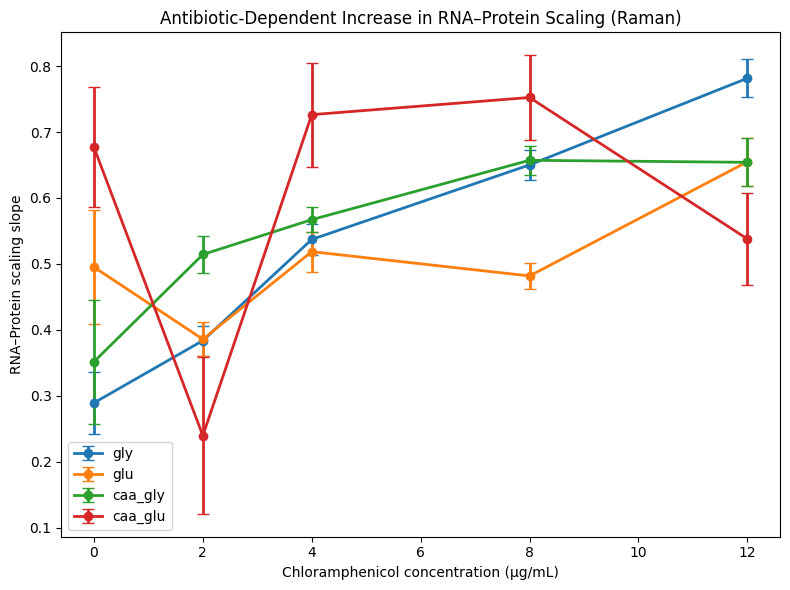

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD RAMAN DATA
# ============================================================
rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")

nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
cm_levels = [0, 2, 4, 8, 12]

# ============================================================
# HELPER: Fit slope + standard error
# ============================================================
def fit_slope_with_std(x, y):
    coef = np.polyfit(x, y, 1)
    y_hat = np.polyval(coef, x)

    n = len(x)
    s_err = np.sqrt(np.sum((y - y_hat)**2) / (n - 2))
    x_mean = np.mean(x)
    Sxx = np.sum((x - x_mean)**2)

    slope_std = s_err / np.sqrt(Sxx)

    return coef[0], slope_std


# ============================================================
# COMPUTE SLOPES
# ============================================================
records = []

for nutrient in nutrients:
    for cm in cm_levels:

        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns or col not in protein_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA  = RNA[:N]
        PROT = PROT[:N]

        if len(RNA) < 5:
            continue

        slope, slope_std = fit_slope_with_std(PROT, RNA)

        records.append({
            "nutrient": nutrient,
            "cm": cm,
            "slope": slope,
            "std": slope_std
        })

df_slopes = pd.DataFrame(records)

# ============================================================
# PLOT: Raman slope vs antibiotic
# ============================================================
plt.figure(figsize=(8,6))

for nutrient in nutrients:
    sub = df_slopes[df_slopes["nutrient"] == nutrient]

    plt.errorbar(
        sub["cm"],
        sub["slope"],
        yerr=sub["std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label=nutrient
    )

plt.xlabel("Chloramphenicol concentration (µg/mL)")
plt.ylabel("RNA–Protein scaling slope")
plt.title("Antibiotic-Dependent Increase in RNA–Protein Scaling (Raman)")
plt.legend()
plt.tight_layout()
plt.show()


In [56]:
# ============================================================
# FULL PIPELINE: SIMULATION + RAMAN → STATISTICAL SUMMARY
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import pyarrow as pa
import pyarrow.ipc as ipc

# ============================================================
# PARAMETERS
# ============================================================
NS_VALUES  = [0.45, 0.74, 1.03, 1.76]
ABX_VALUES = [0, 2, 4, 8, 12]

NR = 7549.0
NX = 300.0
RIBO_RNA_NT = 4565
BURN_IN = 1000.0

nutrients = ["gly", "glu", "caa_gly", "caa_glu"]
cm_levels = [0, 2, 4, 8, 12]

# ============================================================
# HELPERS
# ============================================================

def load_arrow(path):
    with pa.memory_map(path, "r") as src:
        return ipc.open_file(src).read_all().to_pandas()

def compute_protein(df):
    return (df["r(t)"] + df["q(t)"] + df["et(t)"] + df["em(t)"]).to_numpy()

def compute_mass(df):
    r   = df["r(t)"].to_numpy()
    rmm = df["rmm(t)"].to_numpy()
    rmt = df["rmt(t)"].to_numpy()
    rmq = df["rmq(t)"].to_numpy()
    rmr = df["rmr(t)"].to_numpy()
    zmm = df["zmm(t)"].to_numpy()
    zmt = df["zmt(t)"].to_numpy()
    zmq = df["zmq(t)"].to_numpy()
    zmr = df["zmr(t)"].to_numpy()
    q   = df["q(t)"].to_numpy()
    et  = df["et(t)"].to_numpy()
    em  = df["em(t)"].to_numpy()

    ribo_mass = NR * (r + rmm + rmt + rmq + rmr + zmm + zmt + zmq + zmr)
    non_ribo  = NX * (q + et + em)
    return ribo_mass + non_ribo

def compute_RNA_nt(df):
    mm = (df["mm(t)"] + df["rmm(t)"] + df["zmm(t)"]) * (3 * NX)
    mt = (df["mt(t)"] + df["rmt(t)"] + df["zmt(t)"]) * (3 * NX)
    mq = (df["mq(t)"] + df["rmq(t)"] + df["zmq(t)"]) * (3 * NX)
    mr = (df["mr(t)"] + df["rmr(t)"] + df["zmr(t)"]) * (3 * NR)

    r_tot = (
        df["r(t)"] + df["rmm(t)"] + df["rmt(t)"] +
        df["rmq(t)"] + df["rmr(t)"] +
        df["zmm(t)"] + df["zmt(t)"] +
        df["zmq(t)"] + df["zmr(t)"]
    )

    return (mm + mt + mq + mr + r_tot * RIBO_RNA_NT).to_numpy()

def detect_divisions_from_mass(total_mass):
    dx = np.diff(total_mass)
    slope = np.sign(dx)
    dslope = np.diff(slope)
    return np.where(dslope == -2)[0] + 1

def sample_one_per_cycle(total_mass):
    rng = np.random.default_rng(0)
    div_idx = detect_divisions_from_mass(total_mass)
    div_idx = np.concatenate(([0], div_idx, [len(total_mass) - 1]))

    idx = []
    for i in range(len(div_idx) - 1):
        start, end = div_idx[i], div_idx[i+1]
        if end - start > 10:
            idx.append(rng.integers(start+5, end-5))
    return np.array(idx)

def fit_slope(x, y):
    if len(x) < 5:
        return np.nan
    return np.polyfit(x, y, 1)[0]

# ============================================================
# BUILD df_sim (slope, abx, ns)
# ============================================================

sim_records = []

for ns in NS_VALUES:
    for abx in ABX_VALUES:

        if abx == 0:
            path = f"Data/ns{int(ns*100):03d}.arrow"
        else:
            path = f"Data/ns{int(ns*100):03d}/abx{abx}.arrow"

        df = load_arrow(path)
        df = df[df["timestamp"] >= BURN_IN]

        total_mass = compute_mass(df)
        protein = compute_protein(df) / total_mass
        rna = compute_RNA_nt(df) / total_mass

        idx = sample_one_per_cycle(total_mass)
        protein = protein[idx]
        rna = rna[idx]

        slope = fit_slope(protein, rna)

        sim_records.append({
            "ns": ns,
            "abx": abx,
            "slope": slope
        })

df_sim = pd.DataFrame(sim_records)

# ============================================================
# BUILD df_raman (slope, cm, nutrient)
# ============================================================

rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")

raman_records = []

for nutrient in nutrients:
    for cm in cm_levels:

        col = f"Cm{cm}_{nutrient}"

        if col not in rna_df.columns or col not in protein_df.columns:
            continue

        RNA  = rna_df[col].dropna().values
        PROT = protein_df[col].dropna().values

        N = min(len(RNA), len(PROT))
        RNA  = RNA[:N]
        PROT = PROT[:N]

        slope = fit_slope(PROT, RNA)

        raman_records.append({
            "nutrient": nutrient,
            "cm": cm,
            "slope": slope
        })

df_raman = pd.DataFrame(raman_records)

# ============================================================
# FIT OLS MODELS
# ============================================================

model_sim = smf.ols("slope ~ abx + ns + abx:ns", data=df_sim).fit()

df_raman["nutrient_index"] = df_raman["nutrient"].astype("category").cat.codes
model_raman = smf.ols(
    "slope ~ cm + nutrient_index + cm:nutrient_index",
    data=df_raman
).fit()

# ============================================================
# SUMMARY TABLE
# ============================================================

summary_table = pd.DataFrame({
    "Dataset": ["Simulation", "Raman"],
    "Antibiotic p-value": [
        model_sim.pvalues["abx"],
        model_raman.pvalues["cm"]
    ],
    "Nutrient p-value": [
        model_sim.pvalues["ns"],
        model_raman.pvalues["nutrient_index"]
    ],
    "Interaction p-value": [
        model_sim.pvalues["abx:ns"],
        model_raman.pvalues["cm:nutrient_index"]
    ],
    "R-squared": [
        model_sim.rsquared,
        model_raman.rsquared
    ]
})

print("\n=== Statistical Summary (WRONG)===\n")
print(summary_table.round(4))



=== Statistical Summary (WRONG)===

      Dataset  Antibiotic p-value  Nutrient p-value  Interaction p-value  \
0  Simulation              0.0002            0.7744               0.5500   
1       Raman              0.5058            0.0819               0.1145   

   R-squared  
0     0.8541  
1     0.4840  


In [55]:
# ============================================================
# STATISTICAL SUMMARY (Categorical Nutrient for BOTH datasets)
# ============================================================

import statsmodels.formula.api as smf
import pandas as pd

# --- Simulation: treat ns as categorical ---
model_sim = smf.ols(
    "slope ~ abx + C(ns) + abx:C(ns)",
    data=df_sim
).fit()

# --- Raman: treat nutrient as categorical ---
model_raman = smf.ols(
    "slope ~ cm + C(nutrient) + cm:C(nutrient)",
    data=df_raman
).fit()

# --- Extract overall term significance using ANOVA (cleaner for categorical) ---
from statsmodels.stats.anova import anova_lm

anova_sim   = anova_lm(model_sim, typ=2)
anova_raman = anova_lm(model_raman, typ=2)

summary_table = pd.DataFrame({
    "Dataset": ["Simulation", "Raman"],
    "Antibiotic p-value": [
        anova_sim.loc["abx", "PR(>F)"],
        anova_raman.loc["cm", "PR(>F)"]
    ],
    "Nutrient p-value": [
        anova_sim.loc["C(ns)", "PR(>F)"],
        anova_raman.loc["C(nutrient)", "PR(>F)"]
    ],
    "Interaction p-value": [
        anova_sim.loc["abx:C(ns)", "PR(>F)"],
        anova_raman.loc["cm:C(nutrient)", "PR(>F)"]
    ],
    "R-squared": [
        model_sim.rsquared,
        model_raman.rsquared
    ]
})

print("\n=== Statistical Summary (Categorical Nutrient) ===\n")
print(summary_table.round(4))



=== Statistical Summary (Categorical Nutrient) ===

      Dataset  Antibiotic p-value  Nutrient p-value  Interaction p-value  \
0  Simulation              0.0000            0.9767               0.9134   
1       Raman              0.0095            0.8065               0.3812   

   R-squared  
0     0.8584  
1     0.5356  


When nutrient state is treated categorically, antibiotic concentration emerges as the dominant and statistically significant predictor of RNA–protein scaling slope in both the stochastic Scott-based model and independent Raman measurements, while nutrient effects and interaction terms remain weak. This structural alignment supports the interpretation that antibiotic-induced steepening of RNA–protein scaling reflects underlying ribosomal allocation constraints rather than condition-specific artifacts.